In [2]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import transform_to_sequence
from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Jungle](https://www.openml.org/search?type=data&status=active&id=41027)

In [3]:
dataset_id = 41027
train_data, valid_data, test_data, train_labels, valid_labels, test_labels, _, _ = get_openml_data(dataset_id, transform_func=transform_to_sequence)

In [4]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


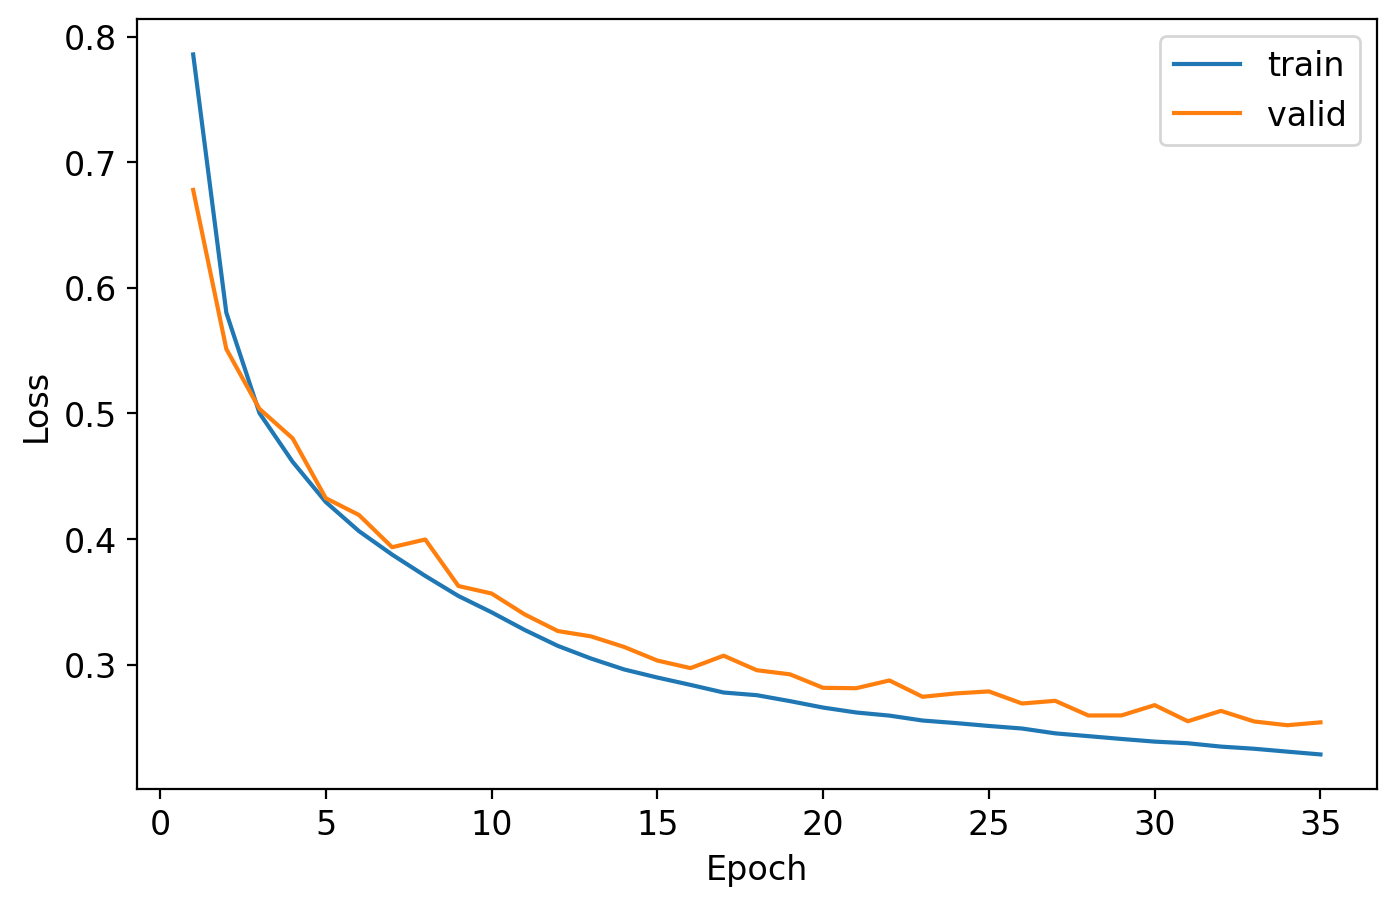

Epoch 35: train loss = 0.2284; valid loss = 0.2540


In [6]:
model_lstm = LSTMClassifier(num_classes=len(np.unique(train_labels))).to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 35, train_loader, valid_loader, criterion, device, scheduler=None)

In [7]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device, multi=True)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob, multi=True)

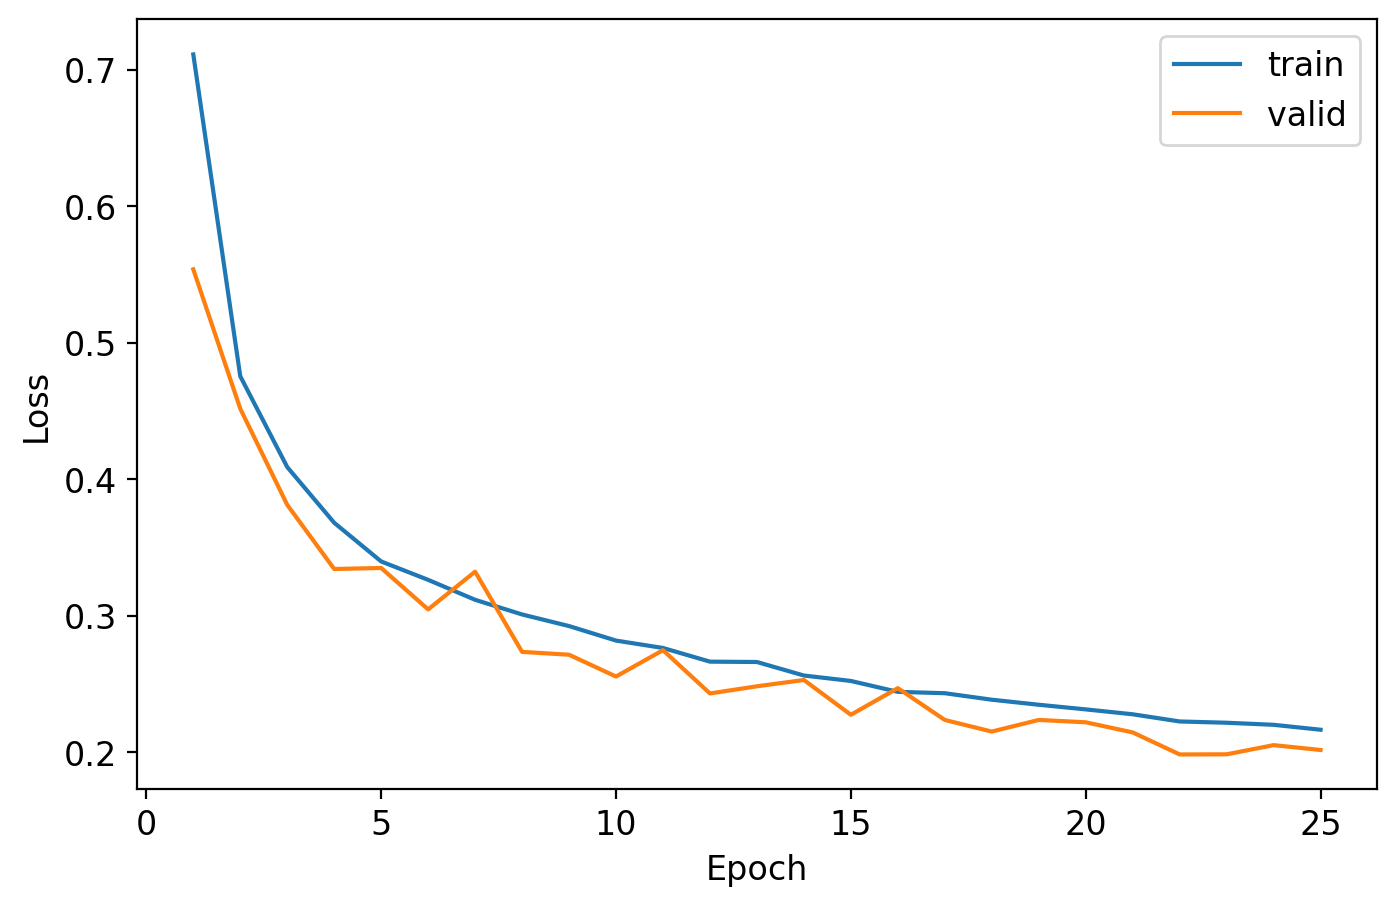

Epoch 25: train loss = 0.2166; valid loss = 0.2017


In [8]:
model_enc = TransformerClassifier(num_classes=len(np.unique(train_labels)), maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 25, train_loader, valid_loader, criterion, device, scheduler=None)

In [9]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device, multi=True)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob, multi=True)

In [10]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.9770±0.0013,0.8339±0.0071,0.8706±0.0050,0.8357±0.0080,0.8324±0.0076
1,Transformer,0.9826±0.0011,0.8465±0.0069,0.8834±0.0047,0.8573±0.0075,0.8372±0.0077
